In [1]:
# PIP MODE: use the installed ras-commander package.
# For local source testing, run Jupyter with PYTHONPATH set to the repo root.

from pathlib import Path
import logging
import shutil

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from shapely.geometry import box

from ras_commander import RasExamples, RasMap
from ras_commander.hdf import HdfLandCover

for logger_name in [
    "ras_commander.RasExamples",
    "ras_commander.RasMap",
    "ras_commander._land_classification_helper",
    "ras_commander.hdf.HdfBase",
    "ras_commander.hdf.HdfLandCover",
]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)


## Developer Mode

When editing ras-commander locally, run this notebook from the repository root with `PYTHONPATH` set to that root before launching Jupyter or `nbconvert`. Restore this pip-mode import cell before committing.

# Land Classification Polygon Authoring

This notebook demonstrates the public `RasMap` API for adding sidecar classification polygons to a copied land-cover layer. The example writes two land-cover override polygons, assigns class IDs and Manning's n roughness values, reads them back through HDF helpers, and plots the override categories on the project land-cover raster.

In [2]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
repo_root = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == "examples"
    else Path.cwd().resolve()
)
WORK_DIR = repo_root / "working" / "CLB-322_land_classification_polygon_authoring"
WORK_DIR.mkdir(parents=True, exist_ok=True)

project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=repo_root / "example_projects",
)
land_classification_layers = RasMap.list_land_classification_layers(project_path)
landcover_layers = RasMap.list_landcover_layers(project_path)
assert not landcover_layers.empty, "Expected a land-cover layer in the example project."

source_hdf = Path(landcover_layers.iloc[0]["resolved_path"])
source_tif = source_hdf.with_suffix(".tif")
assert source_hdf.exists(), source_hdf
assert source_tif.exists(), source_tif

copied_hdf = WORK_DIR / "LandCover_polygon_override_demo.hdf"
copied_tif = copied_hdf.with_suffix(".tif")
shutil.copy2(source_hdf, copied_hdf)
shutil.copy2(source_tif, copied_tif)

print(f"Project: {project_path}")
print(f"Copied sidecar HDF: {copied_hdf}")
print(f"Copied sidecar raster: {copied_tif}")

display(
    land_classification_layers[
        ["name", "classification_kind", "resolved_path"]
    ]
)
display(HdfLandCover.get_landcover_raster_map(copied_hdf).head(8))


Project: C:\GH\symphony-workspaces\ras-commander\CLB-322\example_projects\BaldEagleCrkMulti2D
Copied sidecar HDF: C:\GH\symphony-workspaces\ras-commander\CLB-322\working\CLB-322_land_classification_polygon_authoring\LandCover_polygon_override_demo.hdf
Copied sidecar raster: C:\GH\symphony-workspaces\ras-commander\CLB-322\working\CLB-322_land_classification_polygon_authoring\LandCover_polygon_override_demo.tif


,name,classification_kind,resolved_path
0,LandCover,landcover,C:\GH\symphony-workspaces\ras-commander\CLB-32...
1,Hydrologic Soil Groups,soils,C:\GH\symphony-workspaces\ras-commander\CLB-32...
2,Infiltration,infiltration,C:\GH\symphony-workspaces\ras-commander\CLB-32...


,pixel_value,class_name,mannings_n
0,0,NoData,0.035
1,43,Mixed Forest,0.120
2,41,Deciduous Forest,0.100
3,21,"Developed, Open Space",0.035
4,42,Evergreen Forest,0.150
5,11,Open Water,0.035
6,52,Shrub-Scrub,0.050
7,81,Pasture-Hay,0.045


In [3]:
base_polygons = RasMap.list_land_classification_polygons(copied_hdf)
if base_polygons.empty:
    with rasterio.open(copied_tif) as src:
        minx, miny, maxx, maxy = src.bounds
else:
    minx, miny, maxx, maxy = base_polygons.total_bounds

width = maxx - minx
height = maxy - miny
override_specs = [
    {
        "class_name": "Parking Lot",
        "class_id": 991,
        "mannings_n": 0.105,
        "percent_impervious": 95.0,
        "geometry": box(
            minx + 0.18 * width,
            miny + 0.38 * height,
            minx + 0.30 * width,
            miny + 0.48 * height,
        ),
    },
    {
        "class_name": "Riparian Brush",
        "class_id": 992,
        "mannings_n": 0.070,
        "percent_impervious": 15.0,
        "geometry": box(
            minx + 0.55 * width,
            miny + 0.58 * height,
            minx + 0.67 * width,
            miny + 0.70 * height,
        ),
    },
]

last_result = None
for spec in override_specs:
    last_result = RasMap.add_land_classification_polygon(
        copied_hdf,
        spec["geometry"],
        class_name=spec["class_name"],
        class_id=spec["class_id"],
        variable_values={
            "mannings_n": spec["mannings_n"],
            "percent_impervious": spec["percent_impervious"],
        },
    )

assert last_result is not None
assert last_result.attrs["recompute_required"] is True

polygons = HdfLandCover.get_classification_polygons(copied_hdf)
class_map = HdfLandCover.get_landcover_raster_map(copied_hdf)
created_names = [spec["class_name"] for spec in override_specs]
summary = polygons.loc[polygons["class_name"].isin(created_names)].merge(
    class_map[["pixel_value", "class_name", "mannings_n"]],
    on="class_name",
    how="left",
)
summary["area_sq_ft"] = summary.geometry.area

display(
    summary[
        [
            "polygon_index",
            "class_name",
            "pixel_value",
            "mannings_n",
            "area_sq_ft",
        ]
    ]
)
print(f"Total classification polygons in copied sidecar: {len(polygons)}")
print(f"Recompute required after sidecar edit: {last_result.attrs['recompute_required']}")
print(f"Backup HDF: {last_result.attrs['backup_path']}")


,polygon_index,class_name,pixel_value,mannings_n,area_sq_ft
0,1,Parking Lot,991,0.105,4.236943e+07
1,2,Riparian Brush,992,0.070,5.084332e+07


Total classification polygons in copied sidecar: 3
Recompute required after sidecar edit: True
Backup HDF: C:\GH\symphony-workspaces\ras-commander\CLB-322\working\CLB-322_land_classification_polygon_authoring\LandCover_polygon_override_demo.hdf.bak


Saved map figure: C:\GH\symphony-workspaces\ras-commander\CLB-322\working\CLB-322_land_classification_polygon_authoring\land_classification_polygon_authoring.png


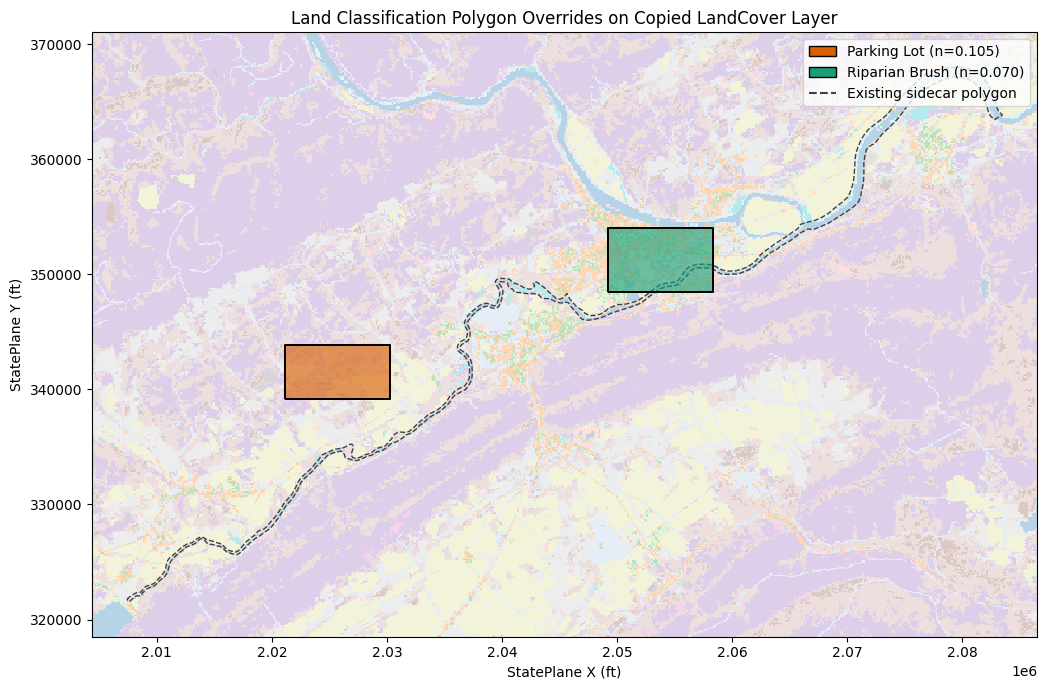

In [4]:
plot_polygons = polygons.loc[polygons["class_name"].isin(created_names)].copy()
context_polygons = polygons.loc[~polygons["class_name"].isin(created_names)].copy()
plot_minx, plot_miny, plot_maxx, plot_maxy = polygons.total_bounds
padding = max(plot_maxx - plot_minx, plot_maxy - plot_miny) * 0.04

with rasterio.open(copied_tif) as src:
    window = from_bounds(
        plot_minx - padding,
        plot_miny - padding,
        plot_maxx + padding,
        plot_maxy + padding,
        transform=src.transform,
    ).round_offsets().round_lengths()
    scale = max(1, int(max(window.width, window.height) // 1100))
    out_height = max(1, int(window.height // scale))
    out_width = max(1, int(window.width // scale))
    landcover_window = src.read(
        1,
        window=window,
        out_shape=(out_height, out_width),
        resampling=Resampling.nearest,
    )
    transform = src.window_transform(window) * src.transform.scale(
        window.width / out_width,
        window.height / out_height,
    )

left, top = transform * (0, 0)
right, bottom = transform * (landcover_window.shape[1], landcover_window.shape[0])
extent = (left, right, bottom, top)

unique_values = np.unique(landcover_window)
value_to_index = {value: index for index, value in enumerate(unique_values)}
indexed_window = np.vectorize(value_to_index.get)(landcover_window)
base_cmap = ListedColormap(
    plt.cm.tab20(np.linspace(0, 1, max(len(unique_values), 1)))
)

override_colors = {
    "Parking Lot": "#d95f02",
    "Riparian Brush": "#1b9e77",
}
n_lookup = dict(zip(class_map["class_name"], class_map["mannings_n"]))

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(
    indexed_window,
    cmap=base_cmap,
    extent=extent,
    origin="upper",
    interpolation="nearest",
    alpha=0.32,
)

if not context_polygons.empty:
    context_polygons.plot(
        ax=ax,
        facecolor="none",
        edgecolor="0.25",
        linewidth=1.0,
        linestyle="--",
    )

for class_name, color in override_colors.items():
    selected = plot_polygons.loc[plot_polygons["class_name"] == class_name]
    selected.plot(
        ax=ax,
        facecolor=color,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.62,
    )
    selected.geometry.boundary.plot(ax=ax, color="black", linewidth=1.4)

handles = [
    Patch(
        facecolor=color,
        edgecolor="black",
        label=f"{class_name} (n={n_lookup[class_name]:.3f})",
    )
    for class_name, color in override_colors.items()
]
if not context_polygons.empty:
    handles.append(
        Line2D(
            [0],
            [0],
            color="0.25",
            linestyle="--",
            label="Existing sidecar polygon",
        )
    )

ax.legend(handles=handles, loc="upper right", frameon=True)
ax.set_title("Land Classification Polygon Overrides on Copied LandCover Layer")
ax.set_xlabel("StatePlane X (ft)")
ax.set_ylabel("StatePlane Y (ft)")
ax.set_aspect("equal")
fig.tight_layout()

figure_path = WORK_DIR / "land_classification_polygon_authoring.png"
fig.savefig(figure_path, dpi=160)
print(f"Saved map figure: {figure_path}")
plt.show()


In [5]:
def _decode(value):
    return value.decode("utf-8").strip() if isinstance(value, bytes) else value


with h5py.File(copied_hdf, "r") as hdf_file:
    polygon_attrs = hdf_file["Classification Polygons/Attributes"][()]
    polygon_info = hdf_file["Classification Polygons/Polygon Info"][()]
    polygon_points = hdf_file["Classification Polygons/Polygon Points"][()]
    variables = hdf_file["Variables"][()]
    raster_map = hdf_file["Raster Map"][()]

audit = pd.DataFrame(
    [
        {
            "dataset": "Classification Polygons/Attributes",
            "rows": len(polygon_attrs),
            "fields": list(polygon_attrs.dtype.names),
        },
        {
            "dataset": "Classification Polygons/Polygon Info",
            "rows": len(polygon_info),
            "fields": ["point_start", "point_count", "part_start", "part_count"],
        },
        {
            "dataset": "Classification Polygons/Polygon Points",
            "rows": len(polygon_points),
            "fields": ["x", "y"],
        },
        {
            "dataset": "Raster Map",
            "rows": len(raster_map),
            "fields": list(raster_map.dtype.names),
        },
        {
            "dataset": "Variables",
            "rows": len(variables),
            "fields": list(variables.dtype.names),
        },
    ]
)
attribute_classes = pd.DataFrame(
    {
        "classification_polygon_class": [
            _decode(row["Classification"]) for row in polygon_attrs
        ]
    }
)

display(audit)
display(attribute_classes)
display(class_map.loc[class_map["class_name"].isin(created_names)])


,dataset,rows,fields
0,Classification Polygons/Attributes,3,[Classification]
1,Classification Polygons/Polygon Info,3,"[point_start, point_count, part_start, part_co..."
2,Classification Polygons/Polygon Points,728,"[x, y]"
3,Raster Map,18,"[ID, Name]"
4,Variables,19,"[Name, ManningsN, Percent Impervious]"


,classification_polygon_class
0,Main Channel
1,Parking Lot
2,Riparian Brush


,pixel_value,class_name,mannings_n
16,991,Parking Lot,0.105
17,992,Riparian Brush,0.070


## Recompute Note

The copied sidecar HDF now contains the new classification polygon records plus the `Raster Map` and `Variables` class rows that carry Manning's n values. The public writer returns `recompute_required=True`; rerun the normal RAS Mapper geometry preprocessing or property-table workflow before treating an already-compiled geometry HDF as updated.